Import of the libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

Reading the csv file 


In [3]:
shop = pd.read_csv('SampleSuperstore.csv')

Listing the top 5 rows

In [4]:
shop.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


Listing the last 5 rows

In [5]:
shop.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


Describing the csv file 


In [7]:
shop.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
shop.dtypes["Profit"]

dtype('float64')

Shape of the csv file 

In [12]:
shop.shape

(9994, 13)

Listing all the columns of the csv file 

In [13]:
shop.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

Checking for the null values if any 

In [20]:
print("\nmissing values before:\n", shop.isnull().sum()[shop.isnull().sum()>0])


missing values before:
 Series([], dtype: int64)


Checking for the duplicates 

In [28]:
duplicates = shop.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")


Duplicate rows found: 0


Droping the duplicates 

In [26]:
shop = shop.drop_duplicates()

Printed the duplicate rows 

In [27]:
print(f"\nDuplicate rows found: {duplicates}")


Duplicate rows found: 17


In [29]:
shop.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [32]:
if 'City' in shop.columns:
    shop['City'] = shop['City'].astype('str')

In [33]:
shop.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Changing the types of attribute 

In [38]:
if 'Sub-Category' in shop.columns:
    shop['Sub-Category'] = shop['Sub-Category'].astype('category')

In [39]:
shop.dtypes

Ship Mode            str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Category             str
Sub-Category    category
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [40]:
if 'Category' in shop.columns:
    shop['Category'] = shop['Category'].astype('category')

In [41]:
shop.dtypes

Ship Mode            str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Category        category
Sub-Category    category
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Checking for the outliers in Quantity 

In [44]:
if 'Quantity' in shop.columns:
    Q1 = shop['Quantity'].quantile(0.25)
    Q3 = shop['Quantity'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((shop['Quantity'] < lower_bound) | (shop['Quantity'] > upper_bound)).sum()
    print(f"\nOutliers in 'Quantity' column: {outliers_count}")
    
    # Treatment: Cap the outliers at the upper and lower bounds (Winsorizing)
    shop['Quantity'] = np.where(shop['Quantity'] > upper_bound, upper_bound, shop['Quantity'])
    shop['Quantity'] = np.where(shop['Quantity'] < lower_bound, lower_bound, shop['Quantity'])


Outliers in 'Quantity' column: 170


Checking for the outliers in Sales 

In [49]:
if 'Sales' in shop.columns:
    Q1 = shop['Sales'].quantile(0.25)
    Q3 = shop['Sales'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((shop['Sales'] < lower_bound) | (shop['Sales'] > upper_bound)).sum()
    print(f"\nOutliers in 'Sales' column: {outliers_count}")
    
    # Treatment: Cap the outliers at the upper and lower bounds (Winsorizing)
    shop['Sales'] = np.where(shop['Sales'] > upper_bound, upper_bound, shop['Sales'])
    shop['Sales'] = np.where(shop['Sales'] < lower_bound, lower_bound, shop['Sales'])


Outliers in 'Sales' column: 0


Checking for the outliers in Price 

In [50]:
if 'Price' in shop.columns:
    Q1 = shop['Price'].quantile(0.25)
    Q3 = shop['Price'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((shop['Price'] < lower_bound) | (shop['Price'] > upper_bound)).sum()
    print(f"\nOutliers in 'Price' column: {outliers_count}")
    
    # Treatment: Cap the outliers at the upper and lower bounds (Winsorizing)
    shop['Price'] = np.where(shop['Price'] > upper_bound, upper_bound, shop['Price'])
    shop['Price'] = np.where(shop['Price'] < lower_bound, lower_bound, shop['Price'])

Checking for the outliers in Discount 

In [51]:
if 'Discount' in shop.columns:
    Q1 = shop['Discount'].quantile(0.25)
    Q3 = shop['Discount'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((shop['Discount'] < lower_bound) | (shop['Discount'] > upper_bound)).sum()
    print(f"\nOutliers in 'Discount' column: {outliers_count}")
    
    # Treatment: Cap the outliers at the upper and lower bounds (Winsorizing)
    shop['Discount'] = np.where(shop['Discount'] > upper_bound, upper_bound, shop['Discount'])
    shop['Discount'] = np.where(shop['Discount'] < lower_bound, lower_bound, shop['Discount'])


Outliers in 'Discount' column: 855


In [53]:
print("\nFinal Data Shape:", shop.shape)


Final Data Shape: (9977, 13)


Saving the cleaned csv file 


In [54]:
shop.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_dataset.csv'")

Cleaned dataset successfully saved as 'cleaned_dataset.csv'


In [55]:
df = pd.read_csv('cleaned_dataset.csv')

Histogram for the quantity 

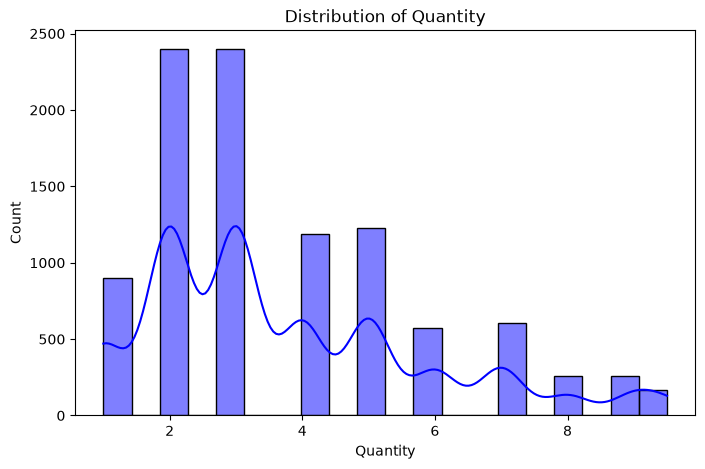

In [61]:
plt.figure(figsize=(8, 5))
# kde=True adds the smooth curve line over the bars
sns.histplot(df['Quantity'], bins=20, kde=True, color='blue')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

Histogram for the sales

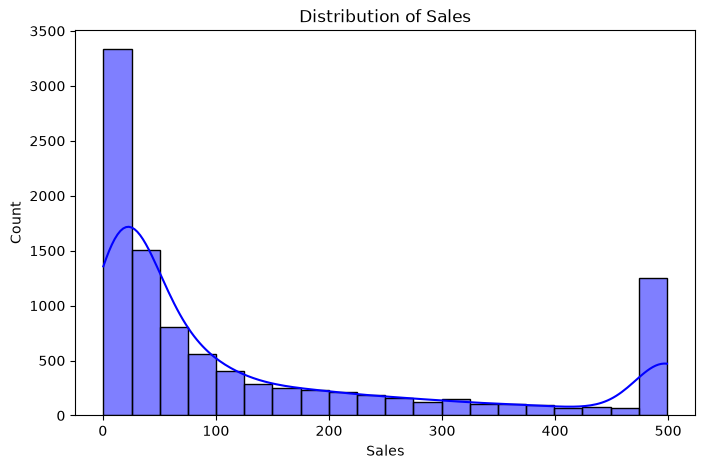

In [62]:
plt.figure(figsize=(8, 5))
# kde=True adds the smooth curve line over the bars
sns.histplot(df['Sales'], bins=20, kde=True, color='blue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.show()

Boxplot for the discount

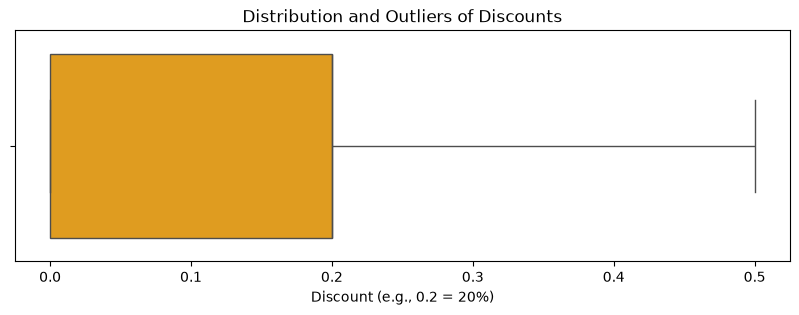

In [65]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Discount'], color='orange')
plt.title('Distribution and Outliers of Discounts')
plt.xlabel('Discount (e.g., 0.2 = 20%)')
plt.show()

Boxplot for quantity

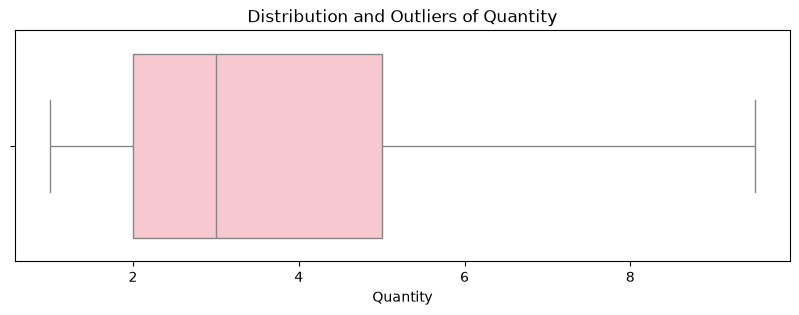

In [66]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Quantity'], color='pink')
plt.title('Distribution and Outliers of Quantity')
plt.xlabel('Quantity')
plt.show()

Barchart for the Category of Product vs Number of Products 

/var/folders/w5/m4c78ckj15j7gfywhxqg8mf00000gn/T/ipykernel_5726/2730278885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis')


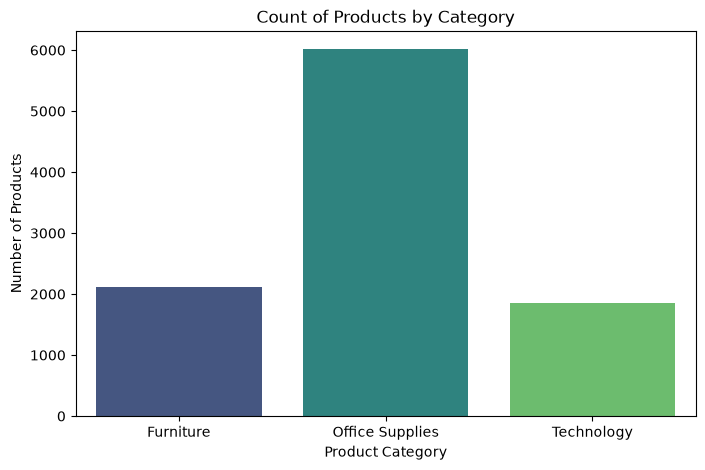

In [74]:
plt.figure(figsize=(8, 5))
# A countplot automatically counts the occurrences of each category
sns.countplot(data=df, x='Category', palette='viridis')
plt.title('Count of Products by Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.show()

Barchart for the Sub-Category of Product vs Number of Products 

/var/folders/w5/m4c78ckj15j7gfywhxqg8mf00000gn/T/ipykernel_5726/868909700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sub-Category', palette='viridis')


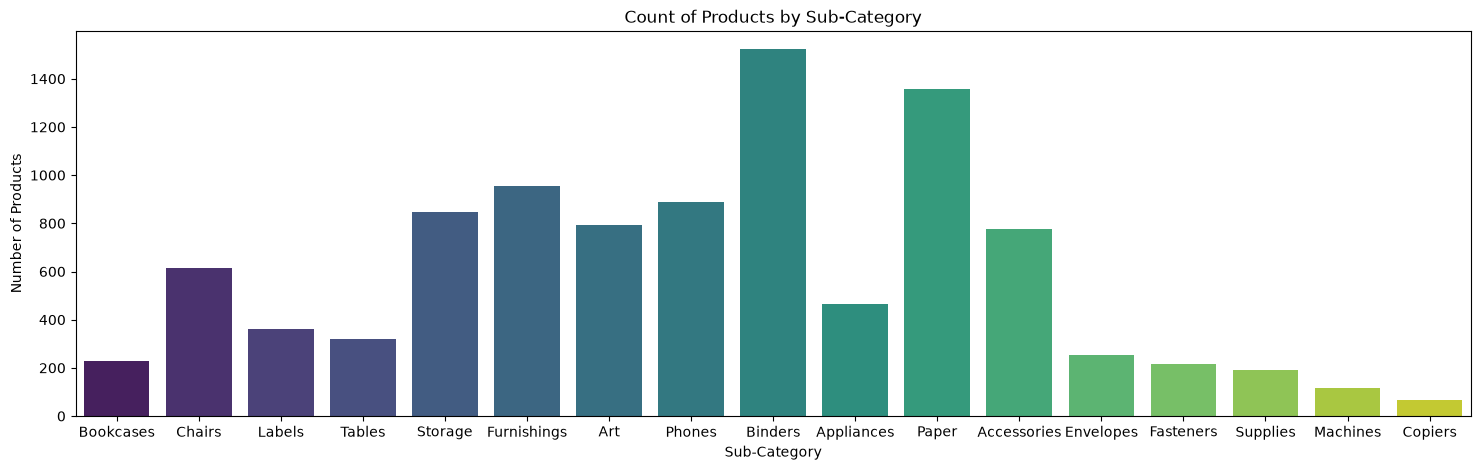

In [77]:
plt.figure(figsize=(18, 5))
# A countplot automatically counts the occurrences of each category
sns.countplot(data=df, x='Sub-Category', palette='viridis')
plt.title('Count of Products by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Number of Products')
plt.show()

Barchart for the Region vs Number of Products 

/var/folders/w5/m4c78ckj15j7gfywhxqg8mf00000gn/T/ipykernel_5726/612954999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', palette='viridis')


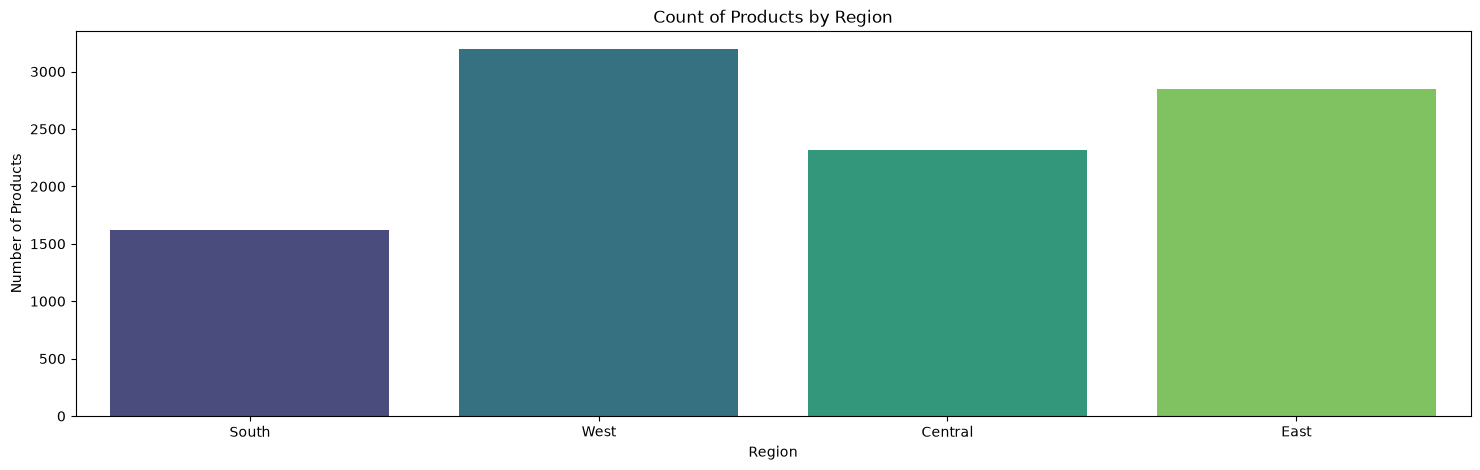

In [80]:
plt.figure(figsize=(18, 5))
# A countplot automatically counts the occurrences of each category
sns.countplot(data=df, x='Region', palette='viridis')
plt.title('Count of Products by Region')
plt.xlabel('Region')
plt.ylabel('Number of Products')
plt.show()

Barchart for the Region vs Segment 

/var/folders/w5/m4c78ckj15j7gfywhxqg8mf00000gn/T/ipykernel_5726/3732072440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', palette='viridis')
/var/folders/w5/m4c78ckj15j7gfywhxqg8mf00000gn/T/ipykernel_5726/3732072440.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Survived')


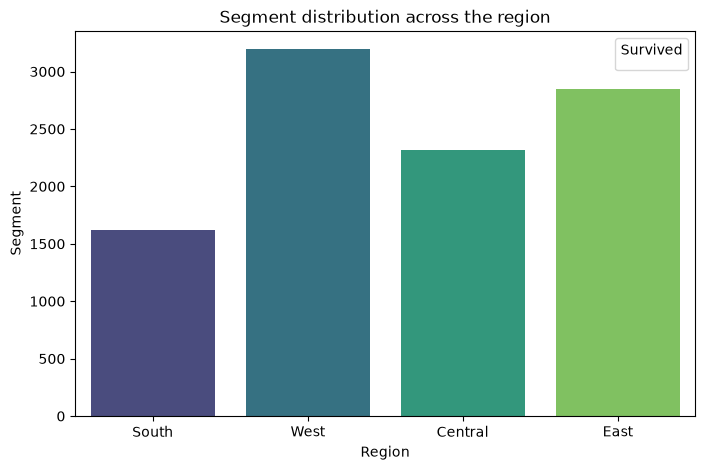

In [87]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Region', palette='viridis')
plt.title('Segment distribution across the region')
plt.xlabel('Region')
plt.ylabel('Segment')
plt.legend(title='Survived')
plt.show()

Barchart for the for Region vs Profit

/var/folders/w5/m4c78ckj15j7gfywhxqg8mf00000gn/T/ipykernel_5726/3721627184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Profit', palette='Blues_d')


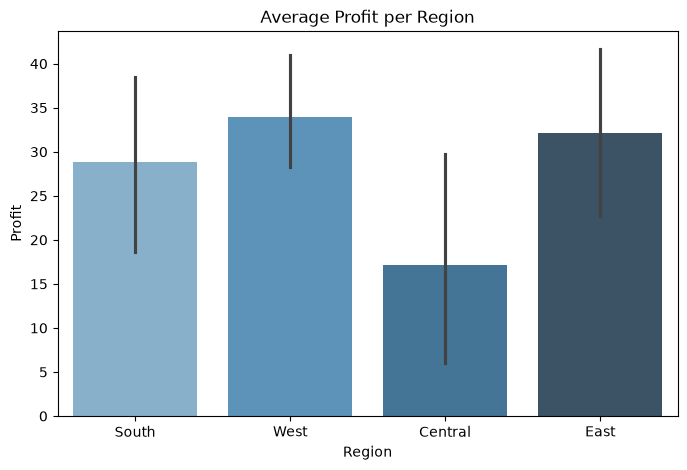

In [91]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Region', y='Profit', palette='Blues_d')
plt.title('Average Profit per Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

1. Distribution of Quantity

    sns.histplot(df['Quantity'], bins=20, kde=True, color='blue')

    Most orders have a quantity between 2 and 5 items, while orders with quantities above 7 are relatively rare. The distribution is positively (right) skewed, indicating that smaller order quantities are much more common than larger ones.

2. Distribution and Outliers of Quantity (Box Plot)

    sns.boxplot(x=df['Quantity'], color='pink')

    The middle 50% of orders have a quantity between approximately 2 and 5 items, with a median of around 3 items. No significant outliers are visible, indicating that order quantities are fairly consistent.

3. Count of Products by Category (Count Plot)

    sns.countplot(data=df, x='Category', palette='viridis')

    Office Supplies is the most frequently ordered product category, while Technology has the fewest products/orders among the three categories.

4. Count of Products by Sub-Category

    sns.countplot(data=df, x='Sub-Category', palette='viridis')

    Binders are the most frequently ordered sub-category, followed by Paper, while Copiers have the lowest number of orders. This indicates that everyday office items are purchased much more often than specialized equipment.

5. Distribution of Orders by Region

    sns.barplot(data=df, x='Region', y='Profit', palette='Blues_d')

    The West region has the highest number of orders, followed by the East region, while the South region has the fewest orders. This indicates that customer activity is strongest in the West and weakest in the South.
